In [2]:
!pip -q install shap

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import shap

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Download Telco Customer Churn dataset from Kaggle

!pip -q install kagglehub

import kagglehub
import os

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Dataset downloaded to:")
print(path)

print("\nFiles available:")
print(os.listdir(path))

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset downloaded to:
/kaggle/input/telco-customer-churn

Files available:
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [5]:
import pandas as pd
import os

csv_file = os.path.join(
    path,
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Remove customer ID because it does not help prediction
df.drop("customerID", axis=1, inplace=True, errors="ignore")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing TotalCharges using median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [7]:
# Estimated customer lifetime value
df["EstimatedLifetimeValue"] = (
    df["MonthlyCharges"] * df["tenure"]
)

# Average monthly spending based on total charges
df["AverageMonthlySpend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

# Customer tenure group
def tenure_group(months):
    if months <= 6:
        return "New"
    elif months <= 24:
        return "Regular"
    else:
        return "Loyal"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

# High monthly charge indicator
median_charge = df["MonthlyCharges"].median()

df["HighMonthlyCharge"] = (
    df["MonthlyCharges"] > median_charge
).astype(int)

display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,EstimatedLifetimeValue,AverageMonthlySpend,TenureGroup,HighMonthlyCharge
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,29.850000,New,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,No,1936.30,55.573529,Loyal,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70,54.075000,New,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50,40.905556,Loyal,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40,75.825000,New,1


In [8]:
df["Churn_Yes"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df.drop("Churn", axis=1, inplace=True)

print(df["Churn_Yes"].value_counts())

Churn_Yes
0    5174
1    1869
Name: count, dtype: int64


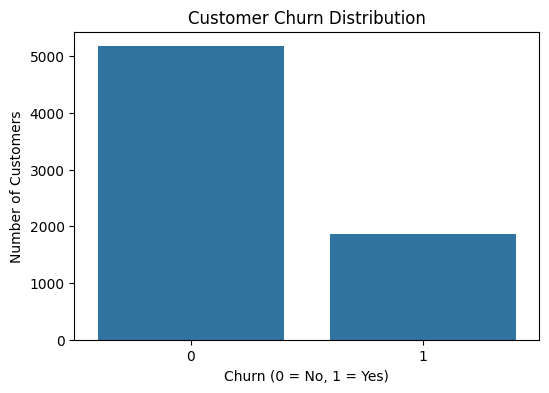

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn_Yes",
    data=df
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

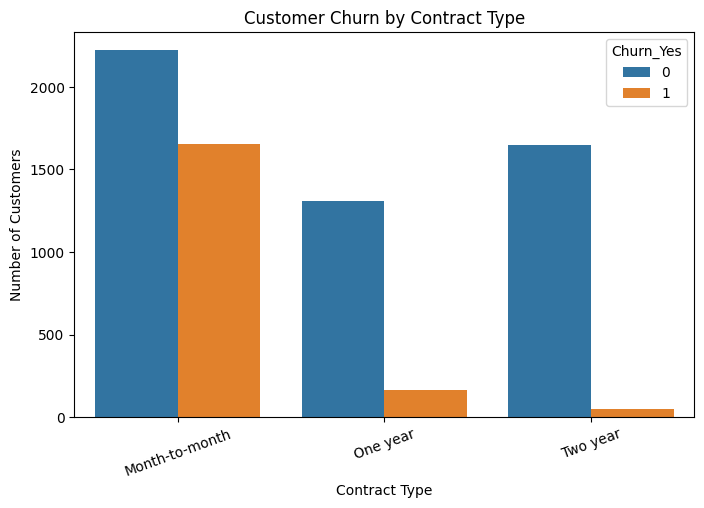

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn_Yes",
    data=df
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

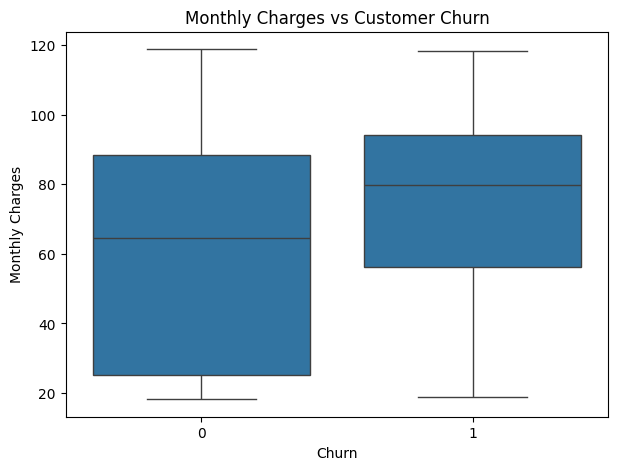

In [11]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Churn_Yes",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

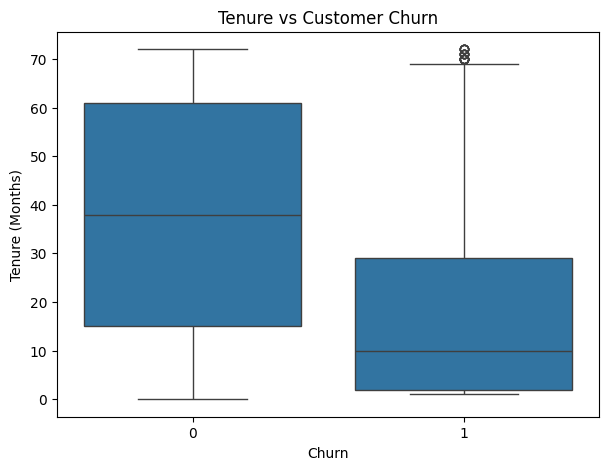

In [12]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Churn_Yes",
    y="tenure",
    data=df
)

plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [13]:
table = pd.crosstab(
    df["Contract"],
    df["Churn_Yes"]
)

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-Square Test")
print("Chi-square value:", round(chi2, 4))
print("P-value:", round(p_value, 5))

if p_value < 0.05:
    print("Contract type has a statistically significant relationship with churn.")
else:
    print("Contract type does not have a statistically significant relationship with churn.")

Chi-Square Test
Chi-square value: 1184.5966
P-value: 0.0
Contract type has a statistically significant relationship with churn.


In [14]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

# One-hot encode categorical variables
X = pd.get_dummies(
    X,
    drop_first=True
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 35)
y shape: (7043,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 35)
Testing data: (1409, 35)


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [17]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    )
}

print("Models created successfully!")

Models created successfully!


In [18]:
results = []

for name, model in models.items():

    # KNN, SVM and Logistic Regression benefit from scaling
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

display(
    results_df.sort_values(
        "F1-Score",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.801278,0.658784,0.521390,0.582090,0.844868
2,KNN,0.782115,0.593838,0.566845,0.580027,0.795961
4,Random Forest,0.801987,0.664360,0.513369,0.579186,0.843682
1,Decision Tree,0.788502,0.619497,0.526738,0.569364,0.825839
3,SVM,0.797729,0.661818,0.486631,0.560863,0.795032


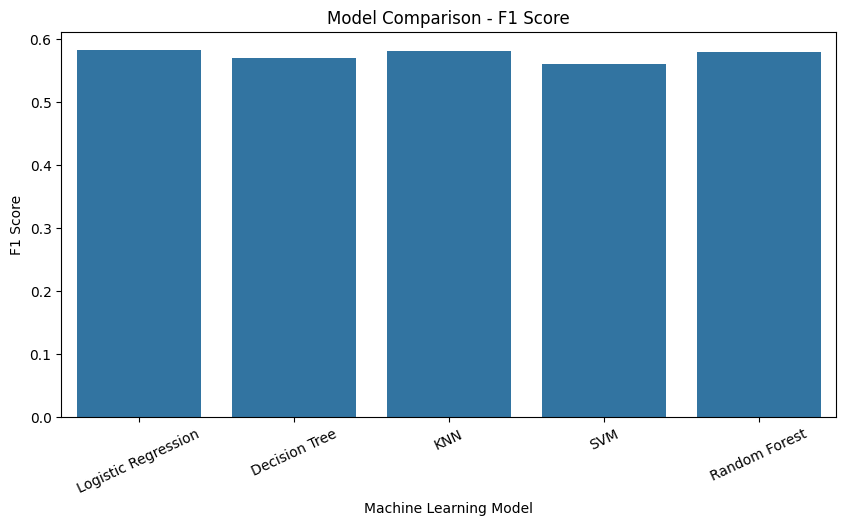

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1-Score"
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=25)

plt.show()

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=cv,
            scoring="f1"
        )
    else:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="f1"
        )

    cv_results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Mean CV F1",
        "Std CV F1"
    ]
)

display(
    cv_df.sort_values(
        "Mean CV F1",
        ascending=False
    )
)

,Model,Mean CV F1,Std CV F1
0,Logistic Regression,0.596764,0.033886
2,KNN,0.562829,0.011840
3,SVM,0.562193,0.016194
4,Random Forest,0.556643,0.013927
1,Decision Tree,0.555343,0.048969


In [21]:
best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [22]:
best_model = models[best_model_name]

if best_model_name in [
    "Logistic Regression",
    "KNN",
    "SVM"
]:
    best_model.fit(
        X_train_scaled,
        y_train
    )

    y_pred_best = best_model.predict(
        X_test_scaled
    )

    y_prob_best = best_model.predict_proba(
        X_test_scaled
    )[:, 1]

else:
    best_model.fit(
        X_train,
        y_train
    )

    y_pred_best = best_model.predict(
        X_test
    )

    y_prob_best = best_model.predict_proba(
        X_test
    )[:, 1]

print("Final model trained successfully!")

Final model trained successfully!


In [23]:
print("MODEL:", best_model_name)
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_prob_best
        ),
        4
    )
)

MODEL: Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8449


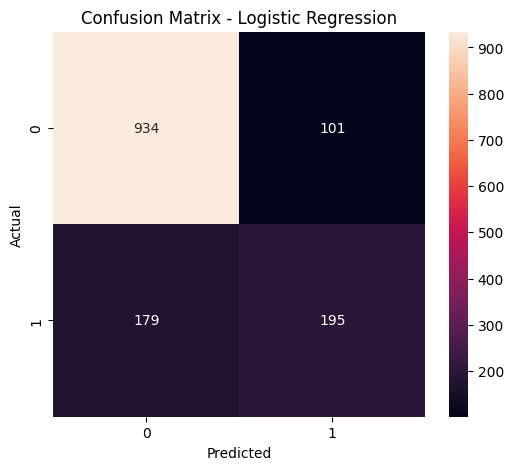

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

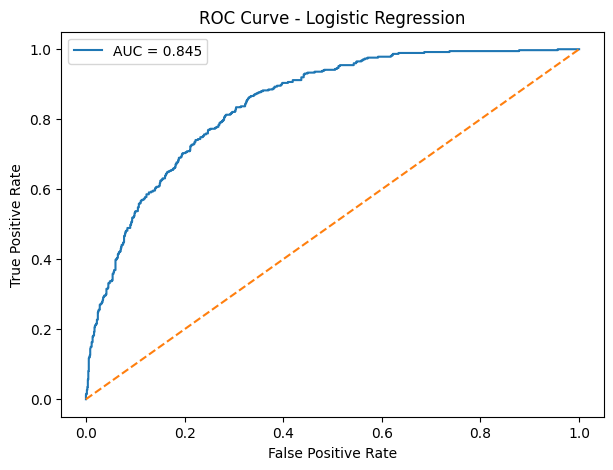

In [25]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_best
)

auc_score = roc_auc_score(
    y_test,
    y_prob_best
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.legend()

plt.show()

In [26]:
def risk_level(probability):

    if probability < 0.40:
        return "LOW"

    elif probability < 0.70:
        return "MEDIUM"

    else:
        return "HIGH"

In [27]:
def retention_recommendation(risk):

    if risk == "HIGH":

        return (
            "Offer a personalized retention discount, "
            "encourage a long-term contract, and provide "
            "priority customer support."
        )

    elif risk == "MEDIUM":

        return (
            "Send a personalized loyalty offer and "
            "increase customer engagement."
        )

    else:

        return (
            "Maintain regular engagement and loyalty benefits."
        )

In [28]:
customer_index = 10

if best_model_name in [
    "Logistic Regression",
    "KNN",
    "SVM"
]:
    probability = best_model.predict_proba(
        X_test_scaled[customer_index].reshape(1, -1)
    )[0][1]

else:
    probability = best_model.predict_proba(
        X_test.iloc[[customer_index]]
    )[0][1]

risk = risk_level(probability)

recommendation = retention_recommendation(risk)

print("CUSTOMER CHURN ANALYSIS")
print("=" * 40)

print(
    f"Churn Probability: {probability * 100:.2f}%"
)

print(
    f"Risk Level: {risk}"
)

print(
    f"Recommended Action: {recommendation}"
)

CUSTOMER CHURN ANALYSIS
Churn Probability: 29.32%
Risk Level: LOW
Recommended Action: Maintain regular engagement and loyalty benefits.


Top 15 Features Influencing Customer Churn:


,Feature,Importance
1,tenure,0.115224
3,TotalCharges,0.113816
4,EstimatedLifetimeValue,0.105264
2,MonthlyCharges,0.088723
5,AverageMonthlySpend,0.081483
13,InternetService_Fiber optic,0.058154
31,PaymentMethod_Electronic check,0.053145
28,Contract_Two year,0.052612
33,TenureGroup_New,0.043004
27,Contract_One year,0.024085


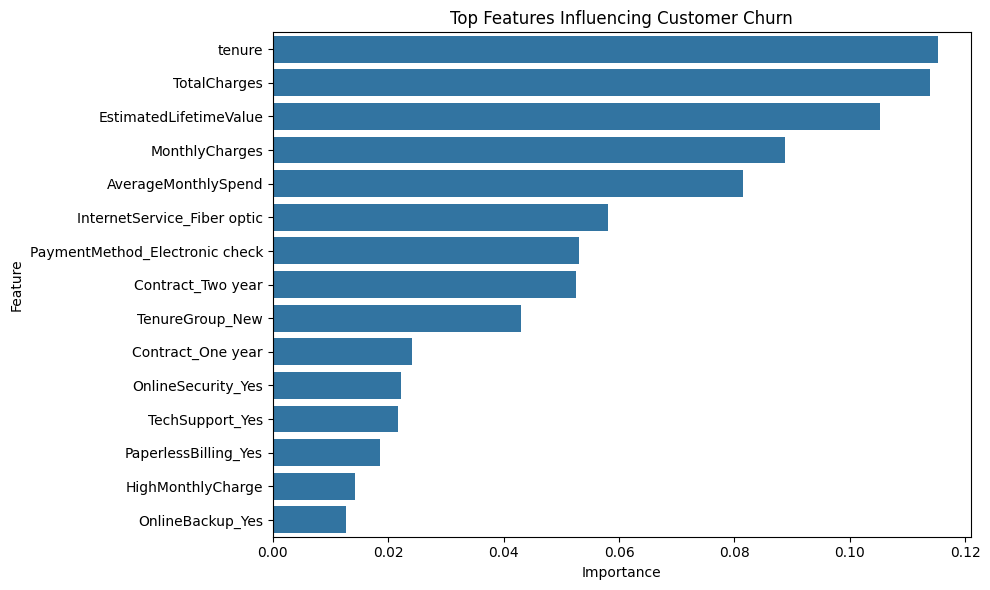

In [29]:
# ============================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================

# Create a new Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Train Random Forest
rf_model.fit(X_train, y_train)

# Get feature importance
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

# Select top 15
top_features = rf_importance.head(15)

# Display table
print("Top 15 Features Influencing Customer Churn:")
display(top_features)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [30]:
# SHAP explanation for Random Forest

explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(
    X_test
)

print("SHAP explanation generated successfully!")

SHAP explanation generated successfully!


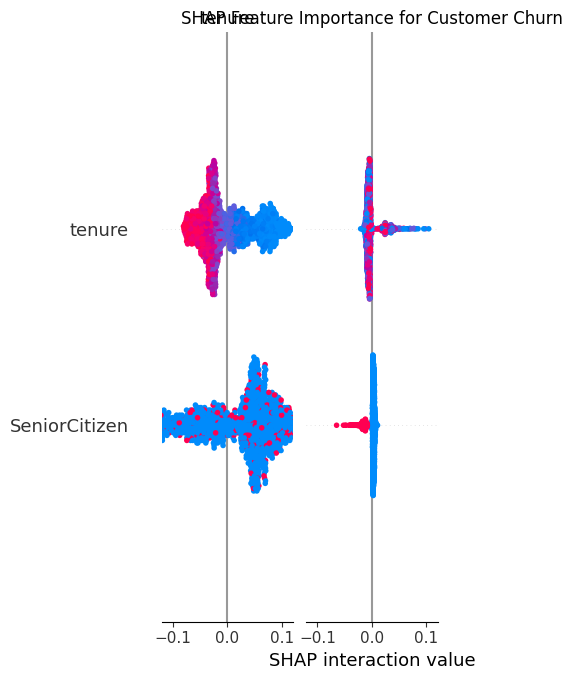

In [31]:
if isinstance(shap_values, list):

    shap.summary_plot(
        shap_values[1],
        X_test,
        show=False
    )

else:

    shap.summary_plot(
        shap_values,
        X_test,
        show=False
    )

plt.title(
    "SHAP Feature Importance for Customer Churn"
)

plt.show()

In [32]:
print("=" * 70)
print("EXPLAINABLE CUSTOMER CHURN PREDICTION SYSTEM")
print("=" * 70)

print(f"Dataset Size: {df.shape[0]} customers")

print(
    f"Number of Features: {X.shape[1]}"
)

print(
    f"Best Model: {best_model_name}"
)

print(
    f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}"
)

print(
    f"Precision: {precision_score(y_test, y_pred_best):.4f}"
)

print(
    f"Recall: {recall_score(y_test, y_pred_best):.4f}"
)

print(
    f"F1 Score: {f1_score(y_test, y_pred_best):.4f}"
)

print(
    f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}"
)

print("=" * 70)

EXPLAINABLE CUSTOMER CHURN PREDICTION SYSTEM
Dataset Size: 7043 customers
Number of Features: 35
Best Model: Logistic Regression
Accuracy: 0.8013
Precision: 0.6588
Recall: 0.5214
F1 Score: 0.5821
ROC-AUC: 0.8449


In [33]:
# ============================================================
# CUSTOMER CHURN PREDICTION FUNCTION
# ============================================================

def predict_customer_churn(customer_index=0):

    # Get one customer from test data
    customer = X_test.iloc[[customer_index]]

    # Predict probability
    if best_model_name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:
        customer_scaled = scaler.transform(customer)

        probability = best_model.predict_proba(
            customer_scaled
        )[0][1]

    else:
        probability = best_model.predict_proba(
            customer
        )[0][1]

    # Determine risk
    risk = risk_level(probability)

    # Recommendation
    recommendation = retention_recommendation(risk)

    print("=" * 60)
    print("       CUSTOMER CHURN PREDICTION")
    print("=" * 60)

    print(f"Churn Probability : {probability * 100:.2f}%")
    print(f"Risk Level        : {risk}")
    print(f"Recommendation    : {recommendation}")

    print("=" * 60)


# Test with customer 0
predict_customer_churn(0)

       CUSTOMER CHURN PREDICTION
Churn Probability : 4.40%
Risk Level        : LOW
Recommendation    : Maintain regular engagement and loyalty benefits.


In [34]:
# ============================================================
# CHURN THRESHOLD ANALYSIS
# ============================================================

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_best >= threshold
    ).astype(int)

    threshold_results.append([
        threshold,
        accuracy_score(y_test, y_pred_threshold),
        precision_score(y_test, y_pred_threshold),
        recall_score(y_test, y_pred_threshold),
        f1_score(y_test, y_pred_threshold)
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

display(threshold_df)

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.30,0.756565,0.528972,0.756684,0.622662
1,0.35,0.772179,0.555556,0.708556,0.622797
2,0.40,0.781405,0.577830,0.655080,0.614035
3,0.45,0.790632,0.607629,0.596257,0.601889
4,0.50,0.801278,0.658784,0.521390,0.582090
5,0.55,0.801278,0.685039,0.465241,0.554140
6,0.60,0.791341,0.696078,0.379679,0.491349


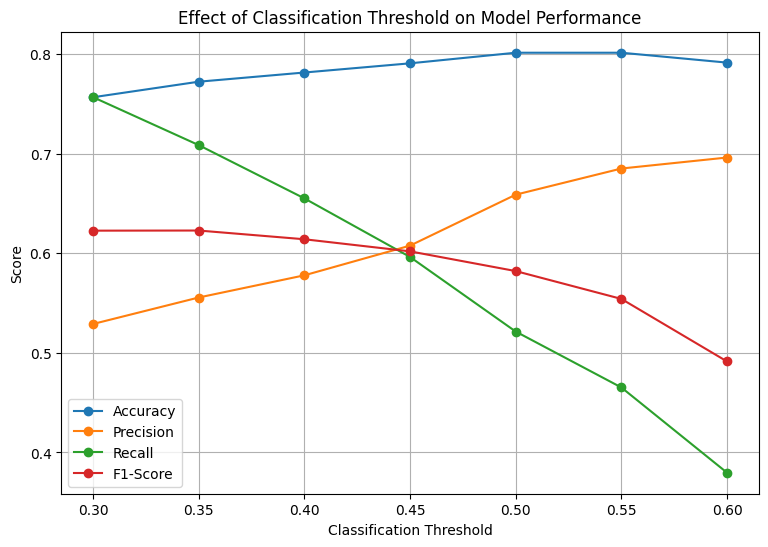

In [35]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Effect of Classification Threshold on Model Performance")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
# ============================================================
# FINAL CHURN PREDICTION SYSTEM
# Threshold = 0.35
# ============================================================

FINAL_THRESHOLD = 0.35

def predict_customer_churn(customer_index=0):

    customer = X_test.iloc[[customer_index]]

    # Get probability
    if best_model_name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:
        customer_scaled = scaler.transform(customer)

        probability = best_model.predict_proba(
            customer_scaled
        )[0][1]

    else:
        probability = best_model.predict_proba(
            customer
        )[0][1]

    # Use optimized threshold
    prediction = int(probability >= FINAL_THRESHOLD)

    # Risk level
    if probability < 0.35:
        risk = "LOW"
    elif probability < 0.60:
        risk = "MEDIUM"
    else:
        risk = "HIGH"

    # Recommendation
    if risk == "HIGH":
        recommendation = (
            "Offer a personalized retention discount, "
            "encourage a long-term contract, and provide "
            "priority customer support."
        )

    elif risk == "MEDIUM":
        recommendation = (
            "Send a personalized loyalty offer and "
            "increase customer engagement."
        )

    else:
        recommendation = (
            "Maintain regular engagement and loyalty benefits."
        )

    print("=" * 65)
    print("        EXPLAINABLE CUSTOMER CHURN PREDICTION")
    print("=" * 65)

    print(f"Model              : {best_model_name}")
    print(f"Churn Probability  : {probability * 100:.2f}%")
    print(f"Decision Threshold : {FINAL_THRESHOLD}")
    print(f"Prediction         : {'CHURN' if prediction else 'NO CHURN'}")
    print(f"Risk Level         : {risk}")
    print(f"Recommendation     : {recommendation}")

    print("=" * 65)


# Test customer
predict_customer_churn(0)

        EXPLAINABLE CUSTOMER CHURN PREDICTION
Model              : Logistic Regression
Churn Probability  : 4.40%
Decision Threshold : 0.35
Prediction         : NO CHURN
Risk Level         : LOW
Recommendation     : Maintain regular engagement and loyalty benefits.


In [37]:
# ============================================================
# EXPLAIN WHY A CUSTOMER IS AT RISK
# ============================================================

def explain_customer(customer_index=0, top_n=5):

    customer = X_test.iloc[[customer_index]]

    # Get prediction probability
    if best_model_name in ["Logistic Regression", "KNN", "SVM"]:
        customer_scaled = scaler.transform(customer)
        probability = best_model.predict_proba(customer_scaled)[0][1]
    else:
        probability = best_model.predict_proba(customer)[0][1]

    # Get Random Forest feature importance
    importance = rf_importance.copy()

    # Top features
    top_features = importance.head(top_n)

    print("=" * 65)
    print("           CUSTOMER CHURN EXPLANATION")
    print("=" * 65)

    print(f"Churn Probability : {probability * 100:.2f}%")

    if probability < 0.35:
        risk = "LOW"
    elif probability < 0.60:
        risk = "MEDIUM"
    else:
        risk = "HIGH"

    print(f"Risk Level        : {risk}")
    print("\nTop Factors Influencing Churn:")
    print("-" * 65)

    for i, row in top_features.iterrows():
        print(
            f"• {row['Feature']} "
            f"(Importance: {row['Importance']:.4f})"
        )

    print("=" * 65)


# Test customer
explain_customer(0)

           CUSTOMER CHURN EXPLANATION
Churn Probability : 4.40%
Risk Level        : LOW

Top Factors Influencing Churn:
-----------------------------------------------------------------
• tenure (Importance: 0.1152)
• TotalCharges (Importance: 0.1138)
• EstimatedLifetimeValue (Importance: 0.1053)
• MonthlyCharges (Importance: 0.0887)
• AverageMonthlySpend (Importance: 0.0815)


In [38]:
# ============================================
# CUSTOMER CHURN PREDICTION FORM
# ============================================

def customer_churn_prediction(customer_index=0):

    customer = X_test.iloc[[customer_index]]

    # Scale input if required
    if best_model_name in ["Logistic Regression", "KNN", "SVM"]:
        customer_scaled = scaler.transform(customer)
        probability = best_model.predict_proba(customer_scaled)[0][1]
    else:
        probability = best_model.predict_proba(customer)[0][1]

    # Risk classification
    if probability < 0.35:
        risk = "LOW"
        recommendation = "Maintain regular engagement and loyalty benefits."
    elif probability < 0.60:
        risk = "MEDIUM"
        recommendation = "Provide a personalized loyalty offer and increase customer engagement."
    else:
        risk = "HIGH"
        recommendation = "Offer a personalized retention discount, long-term contract, and priority support."

    print("=" * 60)
    print("       EXPLAINABLE CUSTOMER CHURN PREDICTION")
    print("=" * 60)
    print(f"Model              : {best_model_name}")
    print(f"Churn Probability  : {probability*100:.2f}%")
    print(f"Decision Threshold : 35%")
    print(f"Prediction         : {'CHURN' if probability >= 0.35 else 'NO CHURN'}")
    print(f"Risk Level         : {risk}")
    print(f"Recommendation     : {recommendation}")
    print("=" * 60)

# Test customer
customer_churn_prediction(0)

       EXPLAINABLE CUSTOMER CHURN PREDICTION
Model              : Logistic Regression
Churn Probability  : 4.40%
Decision Threshold : 35%
Prediction         : NO CHURN
Risk Level         : LOW
Recommendation     : Maintain regular engagement and loyalty benefits.


In [40]:
customer_churn_prediction(20)

       EXPLAINABLE CUSTOMER CHURN PREDICTION
Model              : Logistic Regression
Churn Probability  : 78.53%
Decision Threshold : 35%
Prediction         : CHURN
Risk Level         : HIGH
Recommendation     : Offer a personalized retention discount, long-term contract, and priority support.
